# Notebook Description

In [1]:
from utils import*

# Spike Train Templates

Below we generate 7 template spike trains from which we build template train ensembles.

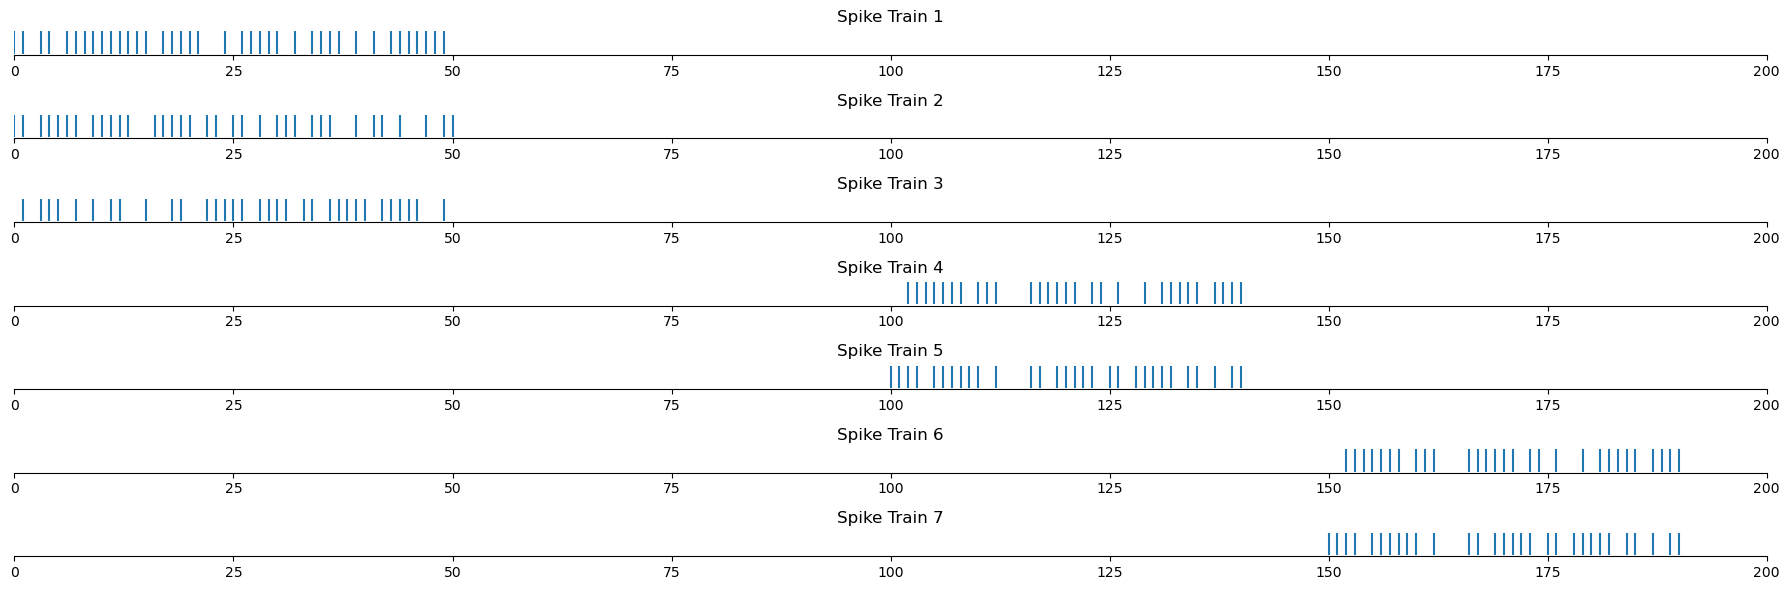

In [2]:
# ==== Generating Template Spike Trains ===
universal_random_state = 1 # fix a universal random seed that will be the key to reproducing everything that follows in this notebook.
## spike train templates 
fire_rate = 0.7
st_temp1 = gen_spike_train(T = 300, prob_map= [(0,50,fire_rate)],random_state = universal_random_state + 1) # fires from 0 to 50 ms with prob fire_rate
st_temp2 = gen_spike_train(T = 300, prob_map = [(0,50,fire_rate)],random_state = universal_random_state + 2)# fires from 0 to 50 ms with prob fire_rate
st_temp3 = gen_spike_train(T = 300, prob_map =[(0,50,fire_rate)], random_state = universal_random_state + 3) # fires from 0 to 50 ms with prob fire_rate
st_temp4 = gen_spike_train(T = 300, prob_map = [(100,140,fire_rate)],random_state = universal_random_state + 4) # fires from 100 to 140 ms with prob fire_rate
st_temp5 = gen_spike_train(T = 300, prob_map = [(100,140,fire_rate)],random_state = universal_random_state + 5) # fires from 100 to 140 ms with prob fire_rate
st_temp6 = shift_spike_train(st_temp4, shift_amount = 50) # identical to st_temp4 but shifted by 50 ms
st_temp7 = shift_spike_train(st_temp5, shift_amount = 50) # identical to st_temp5 but shifted by 50 ms


fig, axes = plt.subplots(7,1, figsize = (18,6))
ax = axes[0]
plot_spike_train(st_temp1,axes =ax)
ax.set_xlim(0,200)
ax.set_title('Spike Train 1')

ax = axes[1]
plot_spike_train(st_temp2,axes =ax)
ax.set_xlim(0,200)
ax.set_title('Spike Train 2')

ax = axes[2]
plot_spike_train(st_temp3,axes =ax)
ax.set_xlim(0,200)
ax.set_title('Spike Train 3')

ax = axes[3]
plot_spike_train(st_temp4,axes =ax)
ax.set_xlim(0,200)
ax.set_title('Spike Train 4')

ax = axes[4]
plot_spike_train(st_temp5,axes =ax)
ax.set_xlim(0,200)
ax.set_title('Spike Train 5')

ax = axes[5]
plot_spike_train(st_temp6,axes =ax)
ax.set_xlim(0,200)
ax.set_title('Spike Train 6')

ax = axes[6]
plot_spike_train(st_temp7,axes =ax)
ax.set_xlim(0,200)
ax.set_title('Spike Train 7')


plt.tight_layout()
plt.show()

# Raster Templates

Using the 7 spike train templates defined above, we generate 4 raster templates. The first two will be labeled as stimulus 1, and the other two as stimulus 2.

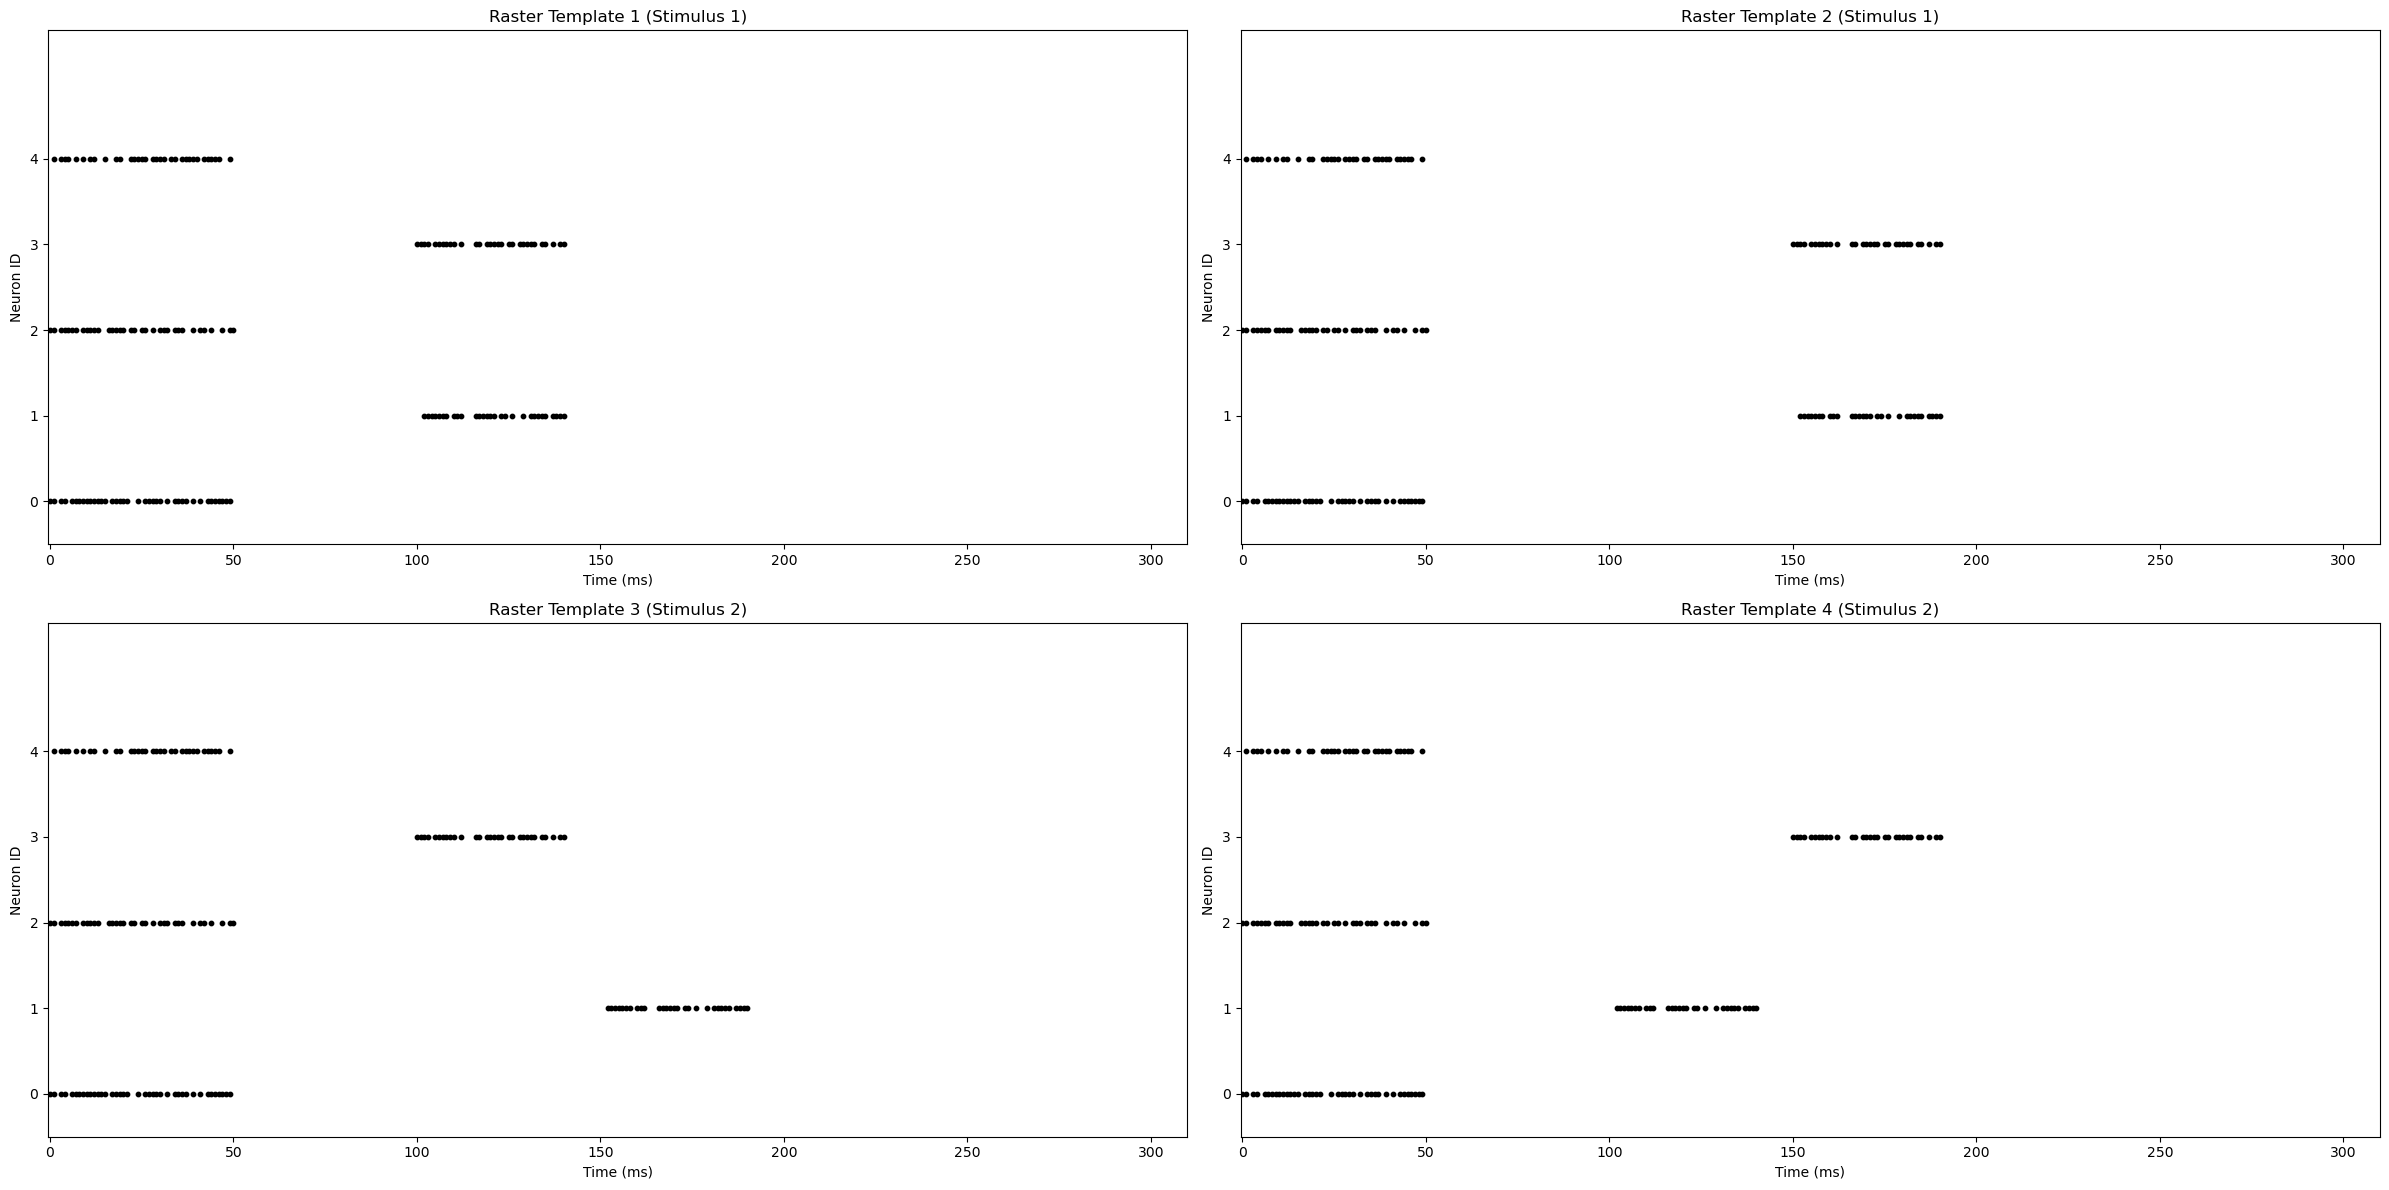

In [3]:
#  ==== Creating raster templates ====
## stimulus 1 templates
### stim 1 will have two templates; first one will have st_temp1, st_temp4, st_temp2, st_temp5, st_temp3 in order from bottom to top. 
### Raster Template 1
raster_temp1 = np.array([st_temp1,st_temp4,st_temp2,st_temp5,st_temp3]) # this is the first template for stimulus 1. It will have st_temp1, st_temp4, st_temp2, st_temp5 ,st_temp3 in order from bottom to top.
                    
### Raster Template 2; this is the second template for stimulus 1. It will have st_temp1, st_temp6, st_temp2, st_temp7 ,st_temp3 in order from bottom to top.
raster_temp2 = np.array([st_temp1,st_temp6,st_temp2,st_temp7,st_temp3]) 

## stimulus 2 templates; this will also have two templates;
### Raster Template 3; this is the first template for stimulus 2. It will have st_temp1, st_temp6, st_temp2, st_temp5, st_temp3 in order from bottom to top.
raster_temp3 = np.array([st_temp1,st_temp6,st_temp2,st_temp5,st_temp3]) # this is the first template for stimulus 2. It will have st_temp1, st_temp6, st_temp2, st_temp5 ,st_temp3 in order from bottom to top.

### Raster Template 4; this is the second template for stimulus 2. It will have st_temp1, st_temp4, st_temp2, st_temp7, st_temp3 in order from bottom to top.
raster_temp4 = np.array([st_temp1,st_temp4,st_temp2,st_temp7,st_temp3])


fig, axs = plt.subplots(2,2,figsize = (24,12))


ax = axs[0][0]
plot_raster(raster_temp1,axes = ax)
ax.set_title('Raster Template 1 (Stimulus 1)')

ax = axs[0][1]
plot_raster(raster_temp2,axes = ax)
ax.set_title('Raster Template 2 (Stimulus 1)')

ax = axs[1][0]
plot_raster(raster_temp3,axes = ax)
ax.set_title('Raster Template 3 (Stimulus 2)')

ax = axs[1][1]
plot_raster(raster_temp4,axes = ax)
ax.set_title('Raster Template 4 (Stimulus 2)')

plt.tight_layout()
plt.show()

# Template Barcodes
We compute the barcodes for the 4 raster templates. Note that template 1 and 2 share the same barcode even though they are different rasters. The same holds true for templates 3 and 4. This gives us some intuition about the fiber of the persistence homology map. This happens because the Victor-Purpura distance does not change with the translation of the spike trains.

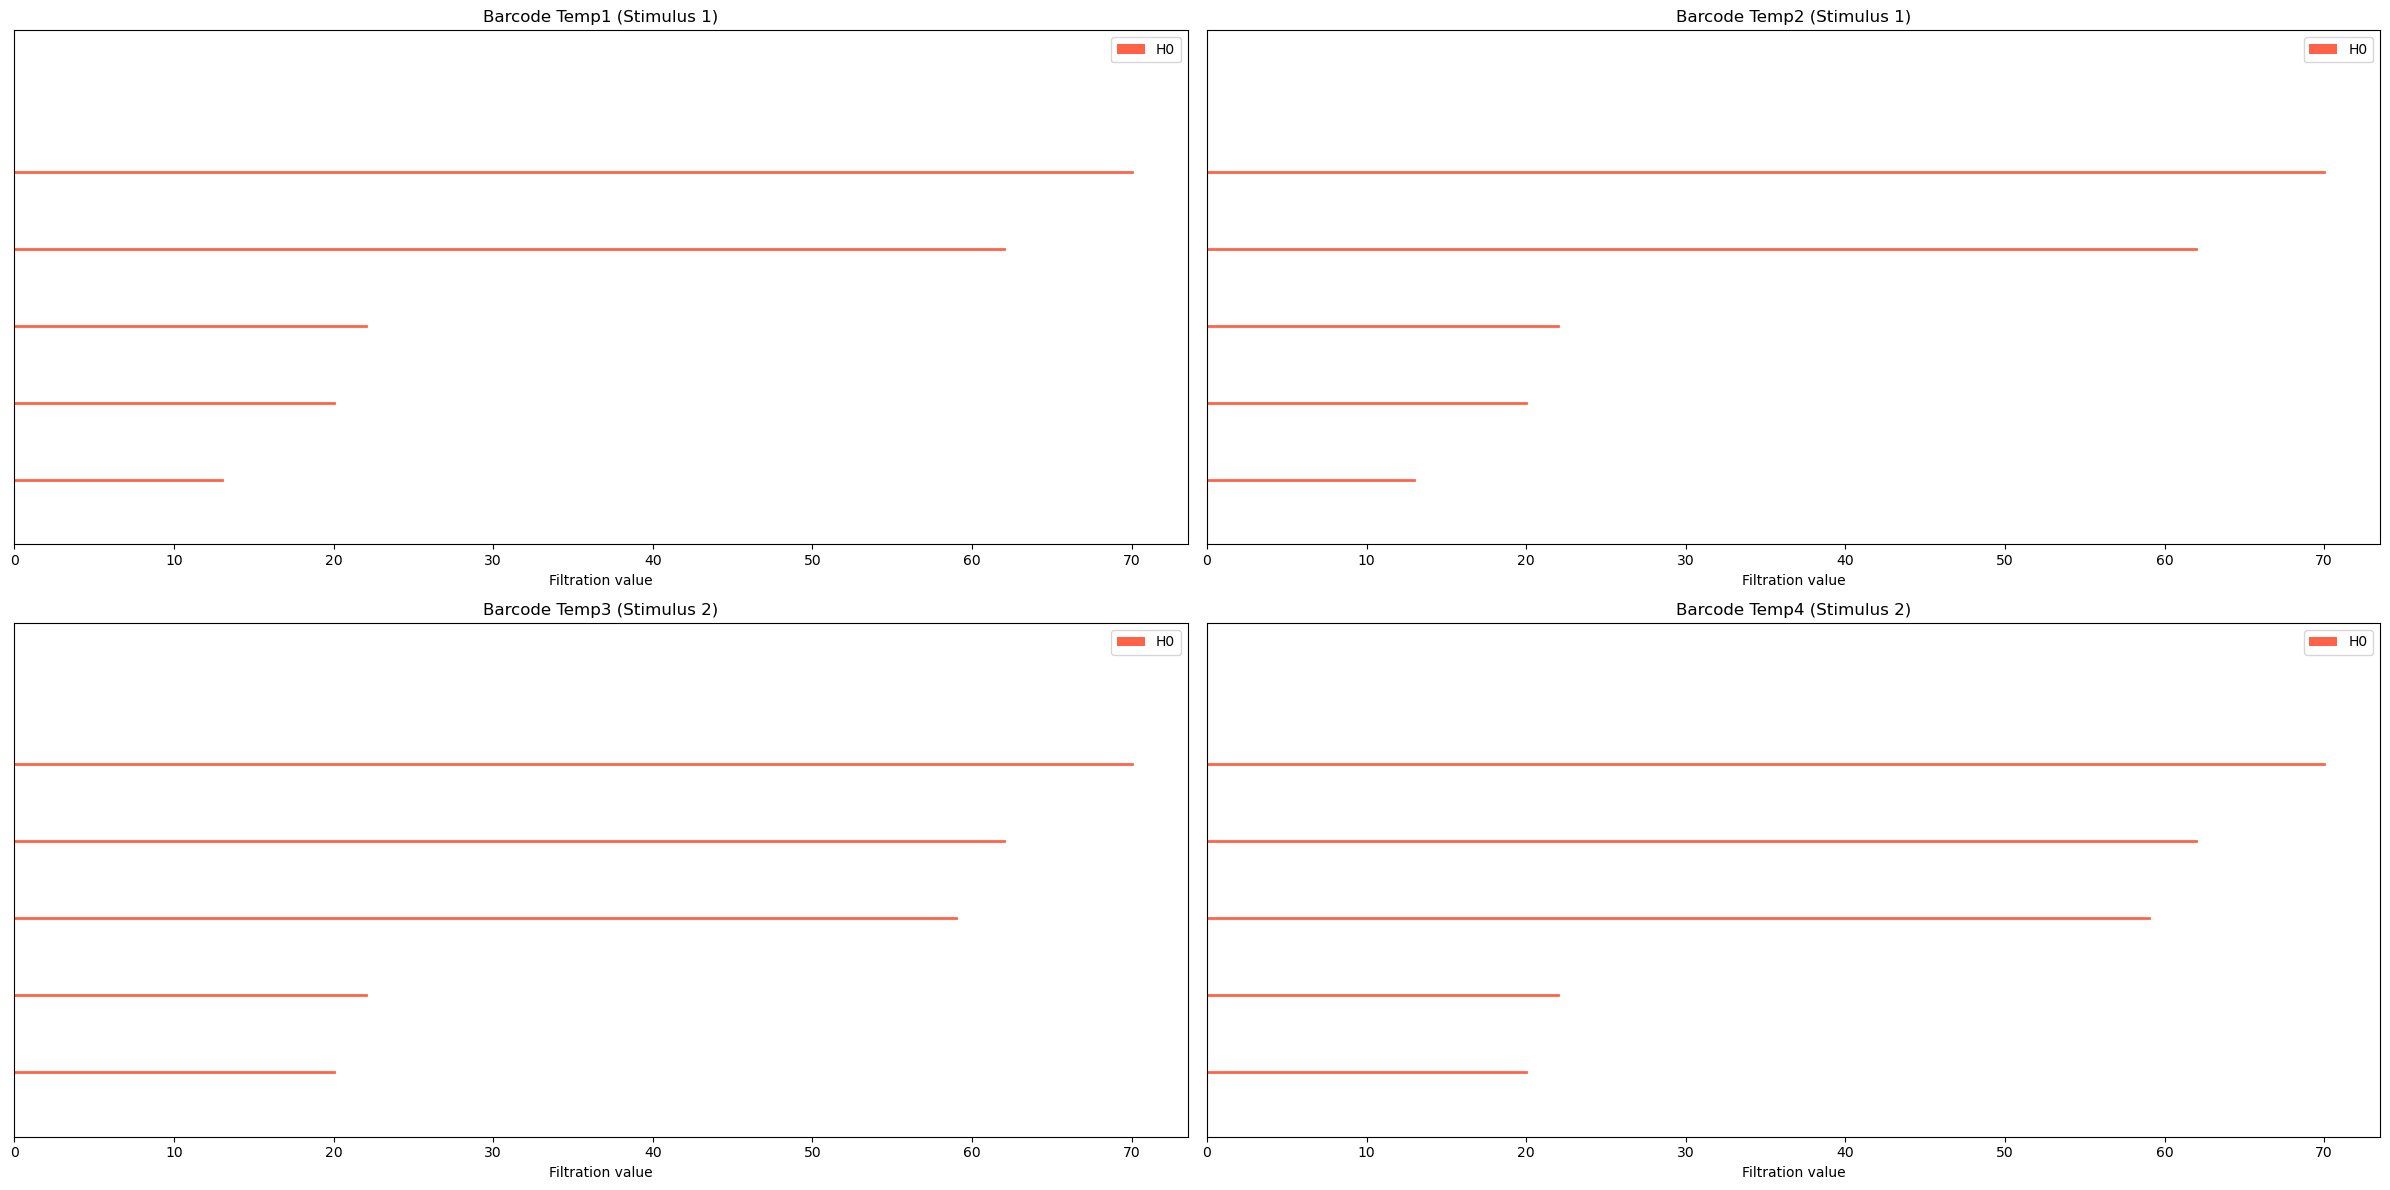

In [4]:
# template barcodes
barcode_temp1 = compute_barcode_from_raster(raster_temp1)
barcode_temp2 = compute_barcode_from_raster(raster_temp2)
barcode_temp3 = compute_barcode_from_raster(raster_temp3)
barcode_temp4 = compute_barcode_from_raster(raster_temp4)


fig, axs = plt.subplots(2,2, figsize = (24,12))

ax = axs[0][0]
plot_barcode(barcode_temp1,ax = ax,r = 70)
ax.set_title('Barcode Temp1 (Stimulus 1)')

ax = axs[0][1]
plot_barcode(barcode_temp2,ax = ax,r = 70)
ax.set_title('Barcode Temp2 (Stimulus 1)')

ax = axs[1][0]
plot_barcode(barcode_temp3,ax = ax,r = 70)
ax.set_title('Barcode Temp3 (Stimulus 2)')

ax = axs[1][1]
plot_barcode(barcode_temp4,ax = ax,r = 70)
ax.set_title('Barcode Temp4 (Stimulus 2)')

plt.tight_layout()
plt.show()

# Generating the Synthetic Datasets Using the Template Rasters
We now generate a dataset using the template rasters. This dataset will consist of 200 trials (rasters) equally distributed between all the templates. We will have 100 trials for stimulus 1 and 100 trials for stimulus 2. Each trial is generated by adding noise to the template rasters. The noise strength can be adjusted to control the variability of the trials. By noise, we mean either adding or removing spikes or shifting spikes in time.

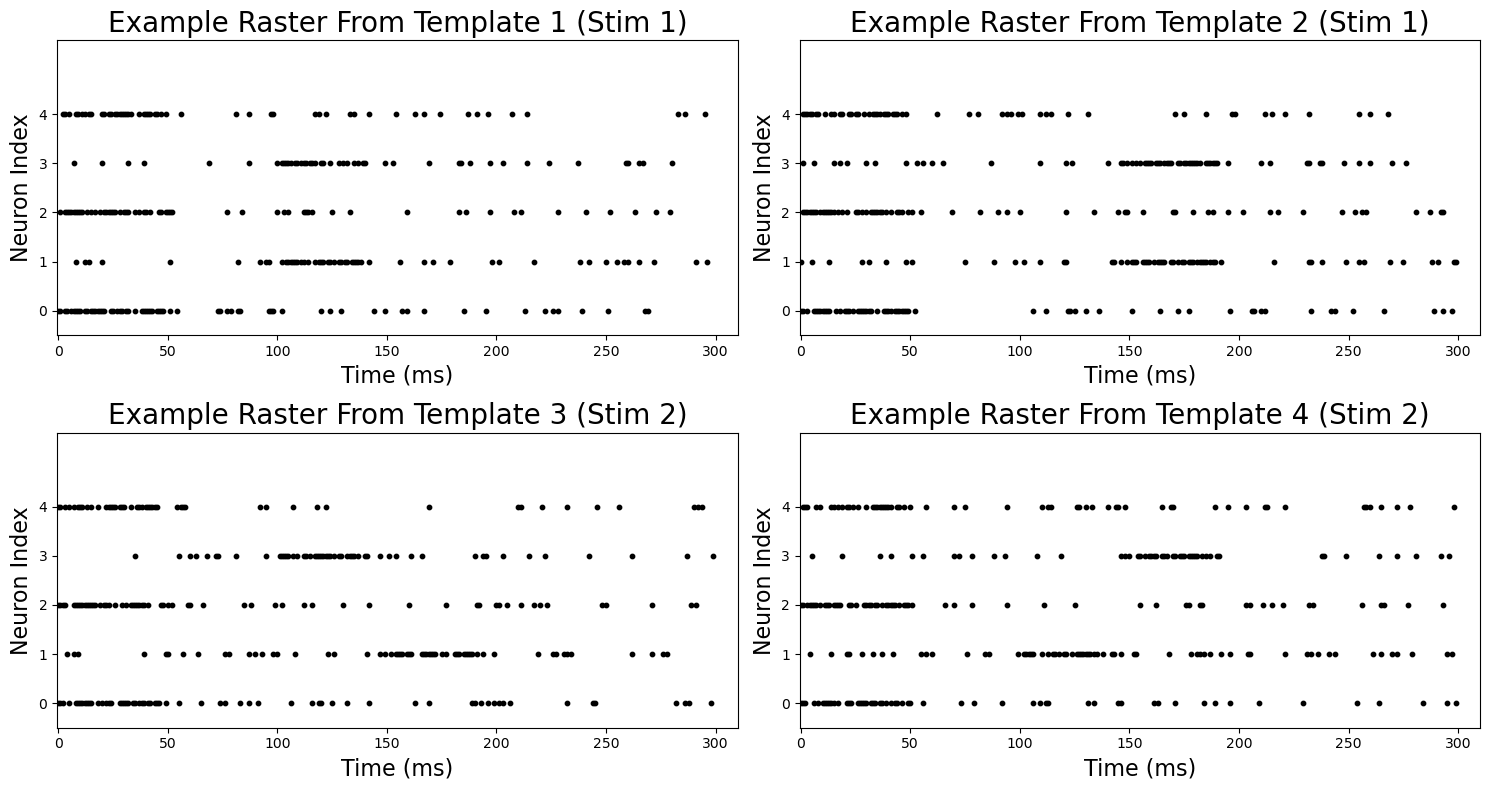

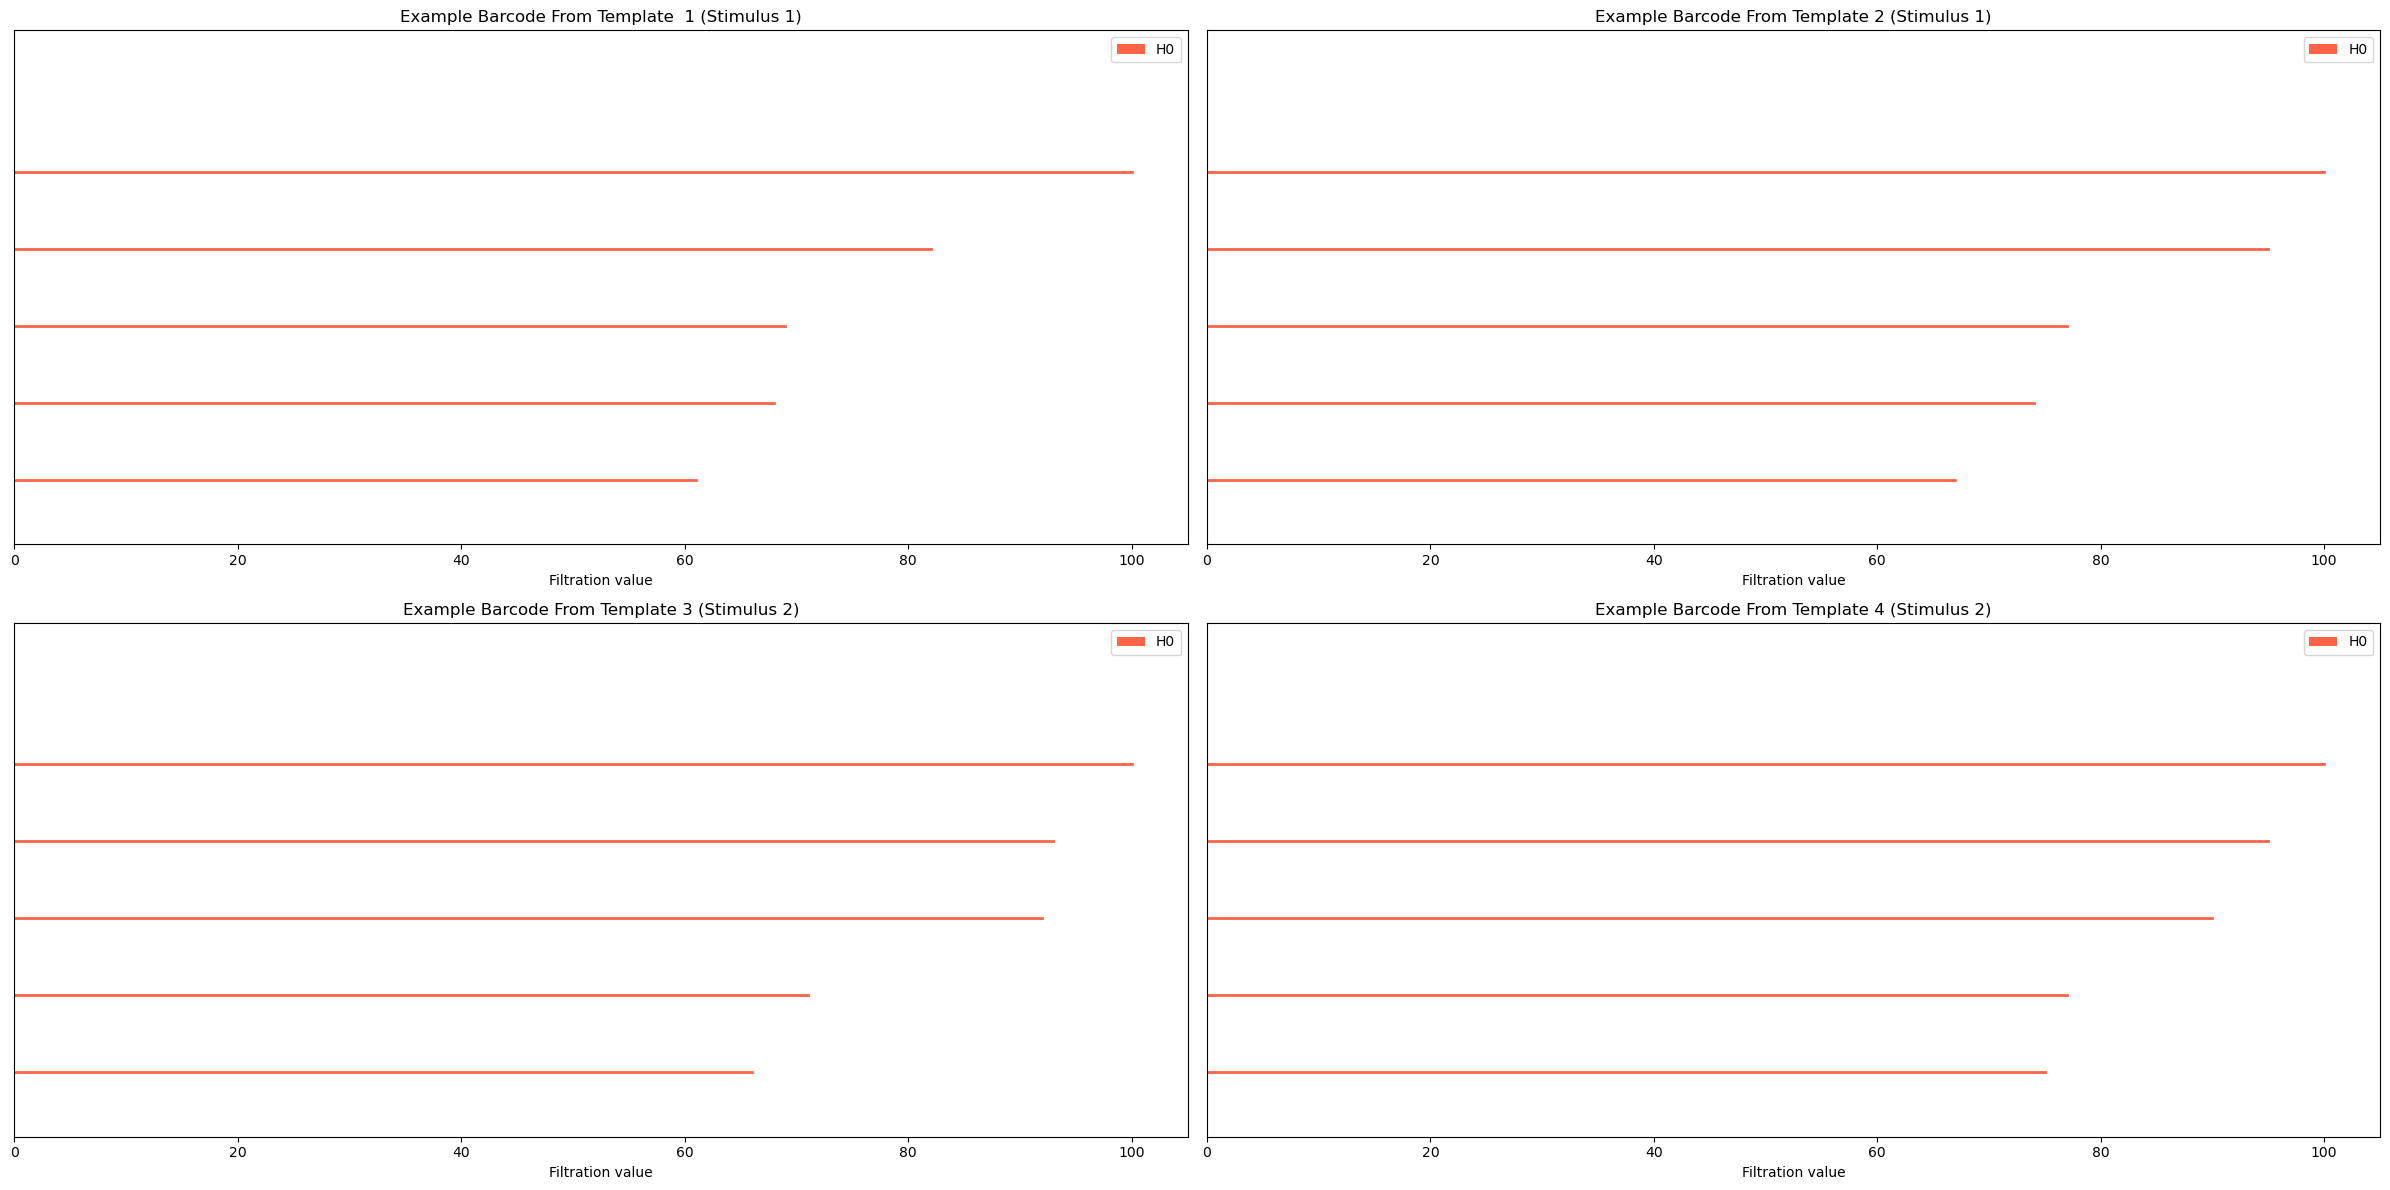

In [5]:
# Generate dataset using the template rasters
n_samples_per_template = 50 # Note: 2*n_samples_per_template will give number of samples per stimulus
rng = np.random.default_rng(universal_random_state) 

# Create a large pool of unique numbers and shuffle it
total_samples = 4 * n_samples_per_template
shuffled_pool = rng.permutation(total_samples)

# Split the shuffled pool into four disjoint lists of random seeds
random_list1, random_list2, random_list3, random_list4 = np.split(shuffled_pool, 4)
random_list = rng.choice(n_samples_per_template, size=n_samples_per_template, replace=False) # list of random seeds. This is also reproducible with the universal_random_state.

# parameters for noise addition
# the noise order is Remove -> Shift -> Add
noise_level_remove = 0.1 # probability of each spike being removed
noise_level_shift = 1.0 # probability of each spike being shifted
shift_strength = 5 # bounds of the shift in ms; if shift_strength = 5, then each spike can be shifted by x ms where x is uniformly sampled from [-5, 5].
noise_level_add = 0.1 # probability of a spike being added to an empty time slot.

# stim 1 rasters
rasters1 = [add_noise_to_raster(raster_temp1,noise_level_shift=noise_level_shift,shift_strength= shift_strength, noise_level_add= noise_level_add, noise_level_remove= noise_level_remove,random_state = random_seed) for random_seed in random_list1]
rasters2 = [add_noise_to_raster(raster_temp2,noise_level_shift=noise_level_shift,shift_strength= shift_strength, noise_level_add= noise_level_add, noise_level_remove= noise_level_remove,random_state = random_seed) for random_seed in random_list2]
rasters_stim1 = rasters1 + rasters2

# stim 2 rasters
rasters3 = [add_noise_to_raster(raster_temp3,noise_level_shift=noise_level_shift,shift_strength= shift_strength, noise_level_add= noise_level_add, noise_level_remove= noise_level_remove,random_state = random_seed) for random_seed in random_list3]
rasters4 = [add_noise_to_raster(raster_temp4,noise_level_shift=noise_level_shift,shift_strength= shift_strength, noise_level_add= noise_level_add, noise_level_remove= noise_level_remove,random_state = random_seed) for random_seed in random_list4]
rasters_stim2 = rasters3 + rasters4

all_rasters = rasters_stim1 + rasters_stim2 # this is our dataset now.

# plot some random rasters
random_int1,random_int2,random_int3,random_int4 = np.random.randint(low =0, high = n_samples_per_template-1, size = 4)

fig, axs = plt.subplots(2,2,figsize = (15,8))
ax = axs[0][0]
plot_raster(rasters1[random_int1],axes = ax)
ax.set_title('Example Raster From Template 1 (Stim 1)',fontsize = 20)
ax.set_xlabel('Time (ms)',fontsize = 16)
ax.set_ylabel('Neuron Index',fontsize = 16)

ax = axs[0][1]
plot_raster(rasters2[random_int2],axes = ax)
ax.set_title('Example Raster From Template 2 (Stim 1)',fontsize = 20)
ax.set_xlabel('Time (ms)',fontsize = 16)
ax.set_ylabel('Neuron Index',fontsize = 16)

ax = axs[1][0]
plot_raster(rasters3[random_int3],axes = ax)
ax.set_title('Example Raster From Template 3 (Stim 2)',fontsize = 20)
ax.set_xlabel('Time (ms)',fontsize = 16)
ax.set_ylabel('Neuron Index',fontsize = 16)

ax = axs[1][1]
plot_raster(rasters4[random_int4],axes = ax)
ax.set_title('Example Raster From Template 4 (Stim 2)',fontsize = 20)
ax.set_xlabel('Time (ms)',fontsize = 16)
ax.set_ylabel('Neuron Index',fontsize = 16)

plt.tight_layout()
# plt.savefig("raster_plots.pdf",format = "pdf")
plt.show()

# Example barcode
ex1 = rasters1[random_int1]
ex2 = rasters2[random_int2]
ex3 = rasters3[random_int3]
ex4 = rasters4[random_int4]

bar1 = compute_barcode_from_raster(ex1)
bar2 = compute_barcode_from_raster(ex2)
bar3 = compute_barcode_from_raster(ex3)
bar4 = compute_barcode_from_raster(ex4)


fig, axs = plt.subplots(2,2, figsize = (24,12))

ax = axs[0][0]
plot_barcode(bar1,ax = ax,r = 100)
ax.set_title('Example Barcode From Template  1 (Stimulus 1)')

ax = axs[0][1]
plot_barcode(bar2,ax = ax,r = 100)
ax.set_title('Example Barcode From Template 2 (Stimulus 1)')

ax = axs[1][0]
plot_barcode(bar3,ax = ax,r = 100)
ax.set_title('Example Barcode From Template 3 (Stimulus 2)')

ax = axs[1][1]
plot_barcode(bar4,ax = ax,r = 100)
ax.set_title('Example Barcode From Template 4 (Stimulus 2)')

plt.tight_layout()
plt.show()


# Perform the TDA pipeline
We now perform the TDA pipeline on the dataset generated above. We report the LOOCv accuracy.

In [6]:
labels = [0]*len(rasters_stim1) + [1] * len(rasters_stim2)

# run tda pipeline
results = TDA_pipeline(rasters = all_rasters,
                                 labels = labels,
                                 time_interval_post = [0,300],
                                 return_bdm = True,
                                 return_barcodes = True,
                                 return_DMs = True              
)


print('LOO Classification Accuracy',results['network_score'])

LOO Classification Accuracy 0.89


## Bottleneck Distance Matrix
We visualize the resulting bottleneck distance matrix, and its corresponding MDS.

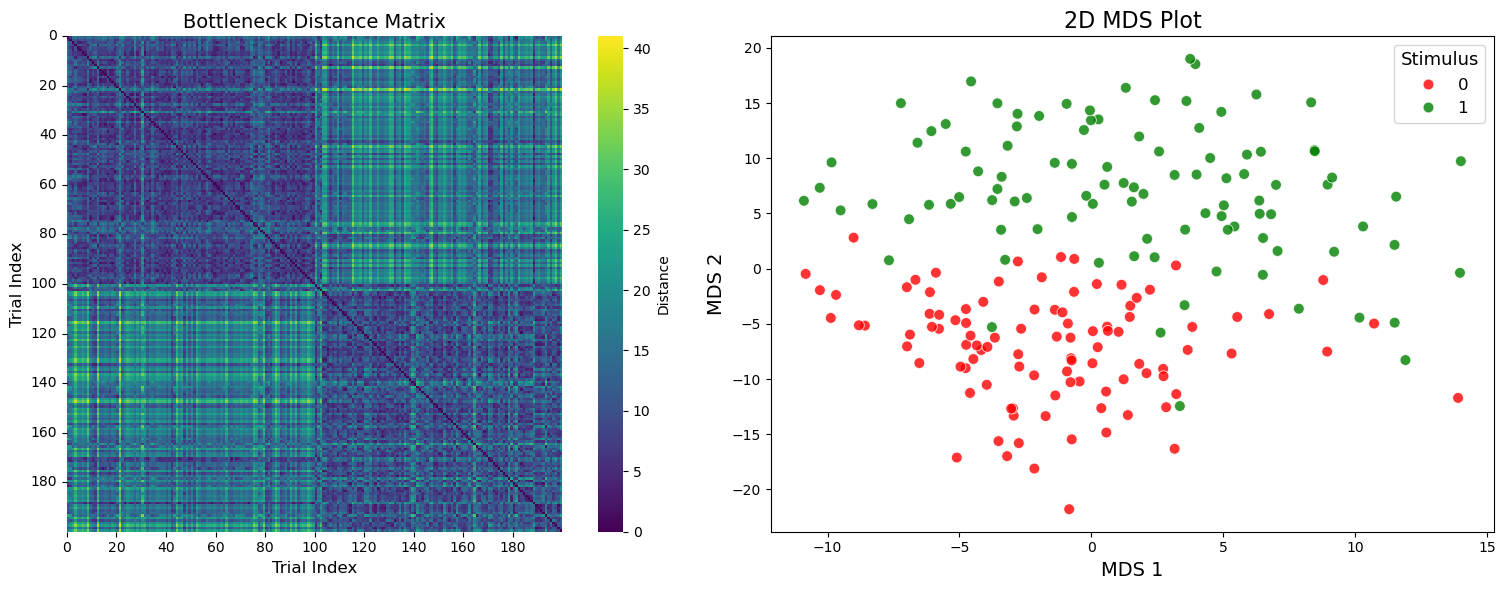

In [10]:
import seaborn as sns
import pandas as pd
from sklearn.manifold import MDS
bdm = results['BDM']
# Compute 2D MDS from the precomputed dissimilarity matrix (bdm)
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=universal_random_state, n_init=4, max_iter=300)
coords = mds.fit_transform(bdm)
labels_np = np.array(labels)

# Plot side-by-side: heatmap (BDM) and 2D MDS scatter
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# Left: heatmap of the Bottleneck Distance Matrix
ax = axs[0]
sns.heatmap(bdm, cmap="viridis", square=True, cbar_kws={'label': 'Distance'}, ax=ax)
n = bdm.shape[0]
# pick a reasonable number of ticks (approx 10) to avoid crowding
ticks = list(range(0, n, max(1, n // 10)))
ax.set_xticks(ticks)
ax.set_xticklabels(ticks, rotation=0)
ax.set_yticks(ticks)
ax.set_yticklabels(ticks, rotation=0)
ax.set_title("Bottleneck Distance Matrix", fontsize=14)
ax.set_xlabel("Trial Index", fontsize=12)
ax.set_ylabel("Trial Index", fontsize=12)

# Right: 2D MDS scatter
ax2 = axs[1]
df = pd.DataFrame({'MDS1': coords[:, 0], 'MDS2': coords[:, 1], 'Stimulus': labels_np})
sns.scatterplot(data=df, x='MDS1', y='MDS2', hue='Stimulus', palette={0: 'red', 1: 'green'}, s=60, alpha=0.8, ax=ax2)
ax2.set_xlabel('MDS 1', fontsize=14)
ax2.set_ylabel('MDS 2', fontsize=14)
ax2.set_title('2D MDS Plot', fontsize=16)
ax2.legend(title='Stimulus', fontsize=12, title_fontsize=13)
ax2.grid(False)

plt.tight_layout()
# Save combined figure
# plt.savefig("bdm_and_mds.pdf", bbox_inches='tight')
plt.show()


# Network Vs Individual Neurons & Statistical Significance test

## TDA Discerns Patterns in Network Activity that are Not Present in Individual Neurons